In [696]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [697]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [698]:
df.shape

(17379, 17)

In [699]:
print(df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [700]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [701]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [702]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


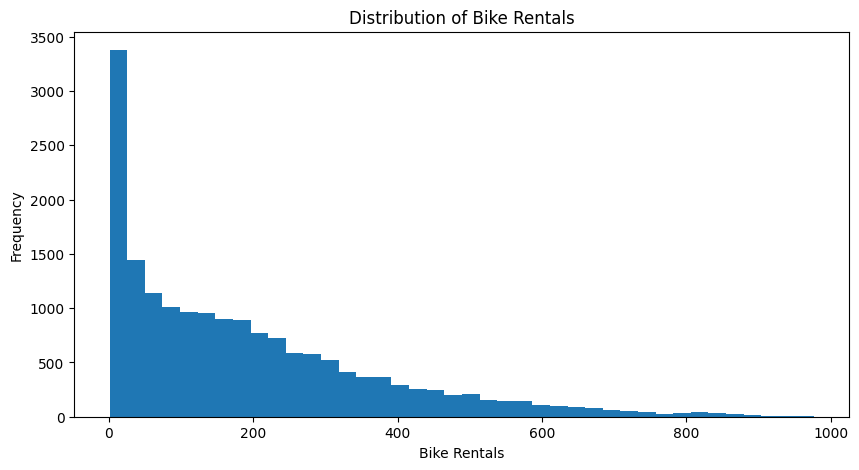

In [703]:
plt.figure(figsize=(10, 5))
plt.hist(df["cnt"], bins=40)
plt.xlabel("Bike Rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rentals")
plt.show()

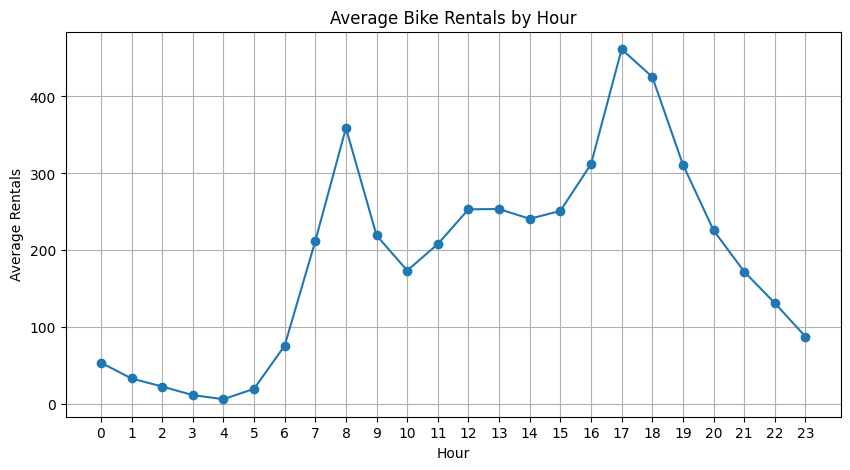

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352
13,253.661180
12,253.315934
15,251.233196
14,240.949246


In [704]:
hour_demand = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hour_demand.index,hour_demand.values,marker="o")

plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

hour_demand.sort_values(ascending=False).head(10)

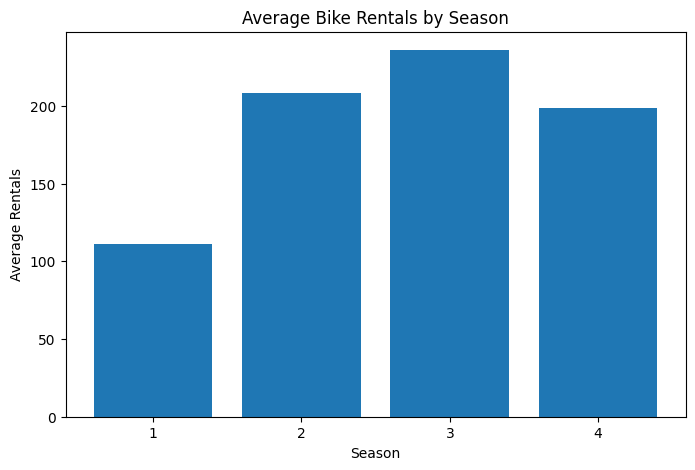

,cnt
season,
1,111.114569
2,208.344069
3,236.016237
4,198.868856


In [705]:
season_demand = df.groupby("season")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(season_demand.index.astype(str),season_demand.values)

plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Season")

plt.show()

season_demand

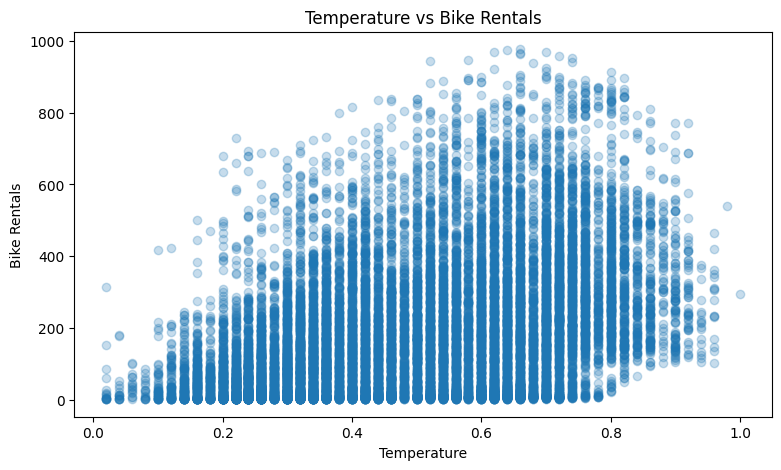

In [706]:
plt.figure(figsize=(9, 5))

plt.scatter(df["temp"],df["cnt"],alpha=0.25)

plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals")

plt.show()

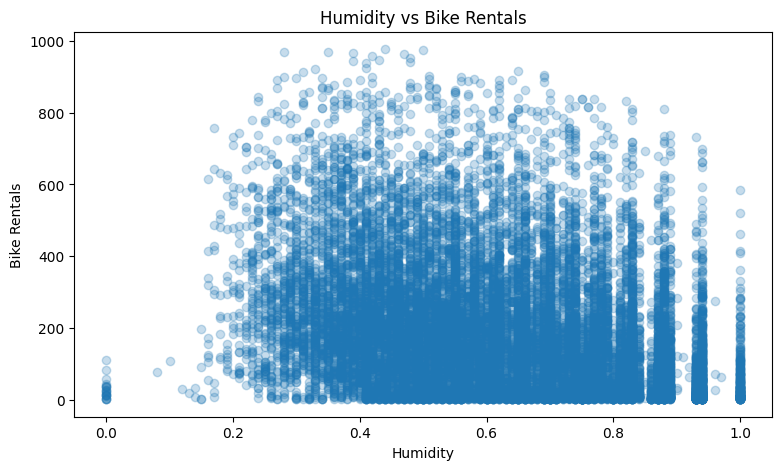

In [707]:
plt.figure(figsize=(9, 5))

plt.scatter(df["hum"],df["cnt"],alpha=0.25)

plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")
plt.title("Humidity vs Bike Rentals")

plt.show()

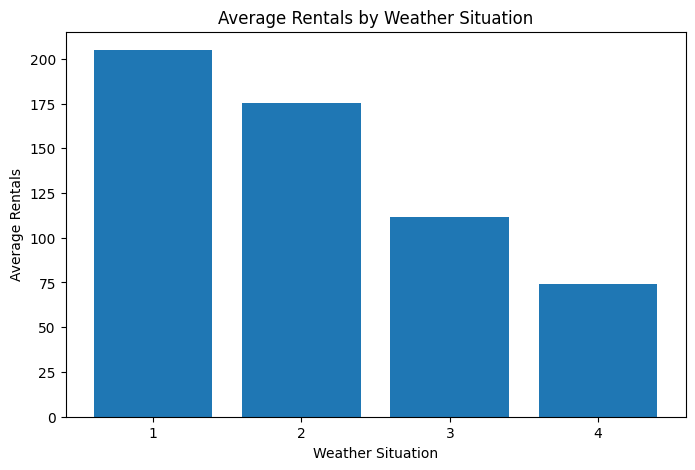

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


In [708]:
weather_demand = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(weather_demand.index.astype(str),weather_demand.values)

plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")
plt.title("Average Rentals by Weather Situation")

plt.show()

weather_demand

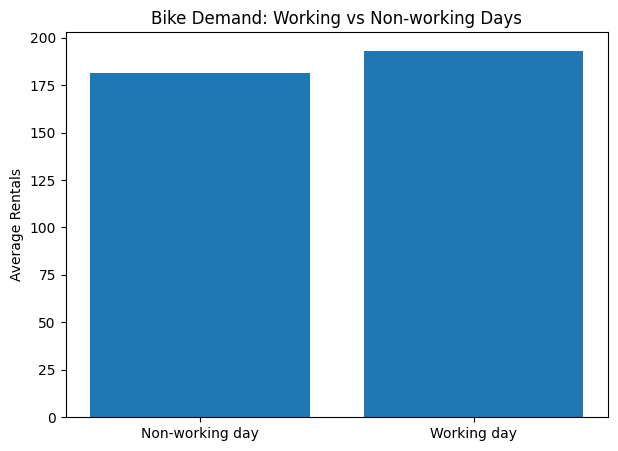

,cnt
workingday,
0,181.405332
1,193.207754


In [709]:
working_demand = df.groupby("workingday")["cnt"].mean()

plt.figure(figsize=(7, 5))

plt.bar(["Non-working day", "Working day"],working_demand.values)

plt.ylabel("Average Rentals")
plt.title("Bike Demand: Working vs Non-working Days")

plt.show()

working_demand

In [710]:
numeric_data = df.select_dtypes(include=np.number)
correlations = numeric_data.corr()["cnt"].sort_values(ascending=False)
correlations

,cnt
cnt,1.000000
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hr,0.394071
instant,0.278379
yr,0.250495
season,0.178056
mnth,0.120638


In [711]:
drop_columns = ["cnt","casual","registered", "instant", "dteday"]
X = df.drop(columns=drop_columns)
y = df["cnt"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (17379, 12)
y shape: (17379,)

Features:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [712]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13903
Testing samples: 3476


In [713]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [714]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression
MAE: 104.80335089554426
MSE: 19379.82836765172
RMSE: 139.21145199893476
R2: 0.38798115831391333


In [715]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20]

knn_scores = []

for k in k_values:

    knn_model = KNeighborsRegressor(n_neighbors=k)

    knn_model.fit(X_train_scaled, y_train)

    y_pred_knn = knn_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred_knn)

    knn_scores.append(mae)

    print("K =", k, "MAE =", mae)

K = 1 MAE = 75.74165707710011
K = 3 MAE = 68.82489451476793
K = 5 MAE = 70.53245109321058
K = 7 MAE = 72.20812099293113
K = 9 MAE = 73.77186421173764
K = 11 MAE = 74.48807406632493
K = 15 MAE = 77.12897967011891
K = 20 MAE = 79.28888089758344


In [716]:
best_k = k_values[np.argmin(knn_scores)]

print("Best K:", best_k)
print("Best MAE:", min(knn_scores))

Best K: 3
Best MAE: 68.82489451476793


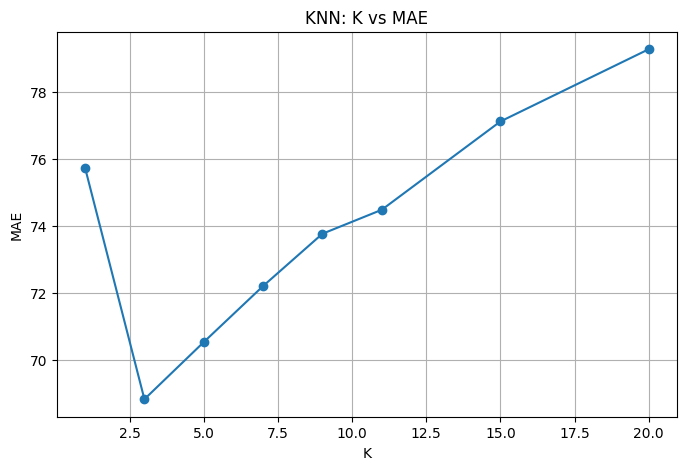

In [717]:
plt.figure(figsize=(8, 5))

plt.plot(k_values,knn_scores,marker="o")

plt.xlabel("K")
plt.ylabel("MAE")
plt.title("KNN: K vs MAE")

plt.grid(True)

plt.show()

In [718]:
knn_model = KNeighborsRegressor(n_neighbors=best_k)

knn_model.fit(X_train_scaled,y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_mae = mean_absolute_error(y_test,y_pred_knn)

knn_mse = mean_squared_error(y_test,y_pred_knn)

knn_rmse = np.sqrt(knn_mse)

knn_r2 = r2_score(y_test,y_pred_knn)

print("KNN Regression")
print("Best K:", best_k)
print("MAE:", knn_mae)
print("MSE:", knn_mse)
print("RMSE:", knn_rmse)
print("R2:", knn_r2)

KNN Regression
Best K: 3
MAE: 68.82489451476793
MSE: 11246.388441375784
RMSE: 106.04899076076012
R2: 0.6448368119435197


In [719]:
depth_values = [3, 5, 8, 10, 15, 20]

tree_scores = []

for depth in depth_values:

    tree_model = DecisionTreeRegressor(max_depth=depth,random_state=42)

    tree_model.fit(X_train,y_train)

    y_pred_tree = tree_model.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred_tree)

    tree_scores.append(mae)

    print("Max Depth =",depth,"MAE =",mae)

Max Depth = 3 MAE = 89.82386451877731
Max Depth = 5 MAE = 70.24142047070586
Max Depth = 8 MAE = 45.469690386777714
Max Depth = 10 MAE = 35.707824765118346
Max Depth = 15 MAE = 33.4204241086192
Max Depth = 20 MAE = 34.239204627355306


In [720]:
best_depth = depth_values[np.argmin(tree_scores)]

print("Best Max Depth:", best_depth)
print("Best MAE:", min(tree_scores))

Best Max Depth: 15
Best MAE: 33.4204241086192


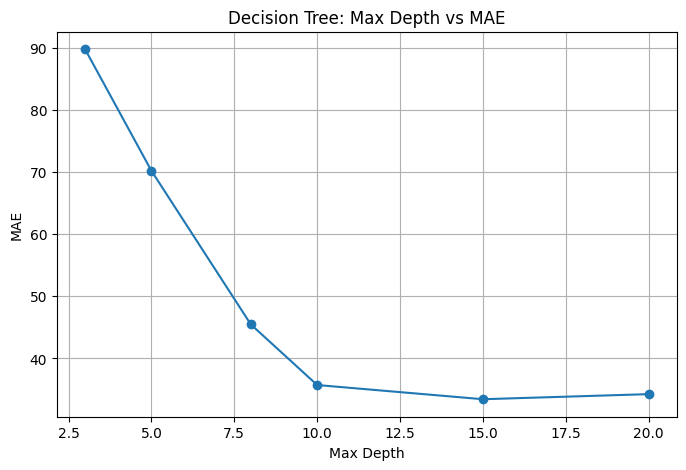

In [721]:
plt.figure(figsize=(8, 5))

plt.plot(depth_values,tree_scores,marker="o")

plt.xlabel("Max Depth")
plt.ylabel("MAE")
plt.title("Decision Tree: Max Depth vs MAE")

plt.grid(True)

plt.show()

In [722]:
tree_model = DecisionTreeRegressor(max_depth=best_depth,random_state=42)

tree_model.fit(X_train,y_train)

y_pred_tree = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test,y_pred_tree)

tree_mse = mean_squared_error(y_test,y_pred_tree)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(y_test,y_pred_tree)

print("Decision Tree Regression")
print("Best Max Depth:", best_depth)
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R2:", tree_r2)

Decision Tree Regression
Best Max Depth: 15
MAE: 33.4204241086192
MSE: 3345.218696407094
RMSE: 57.83786559345957
R2: 0.8943573269627574


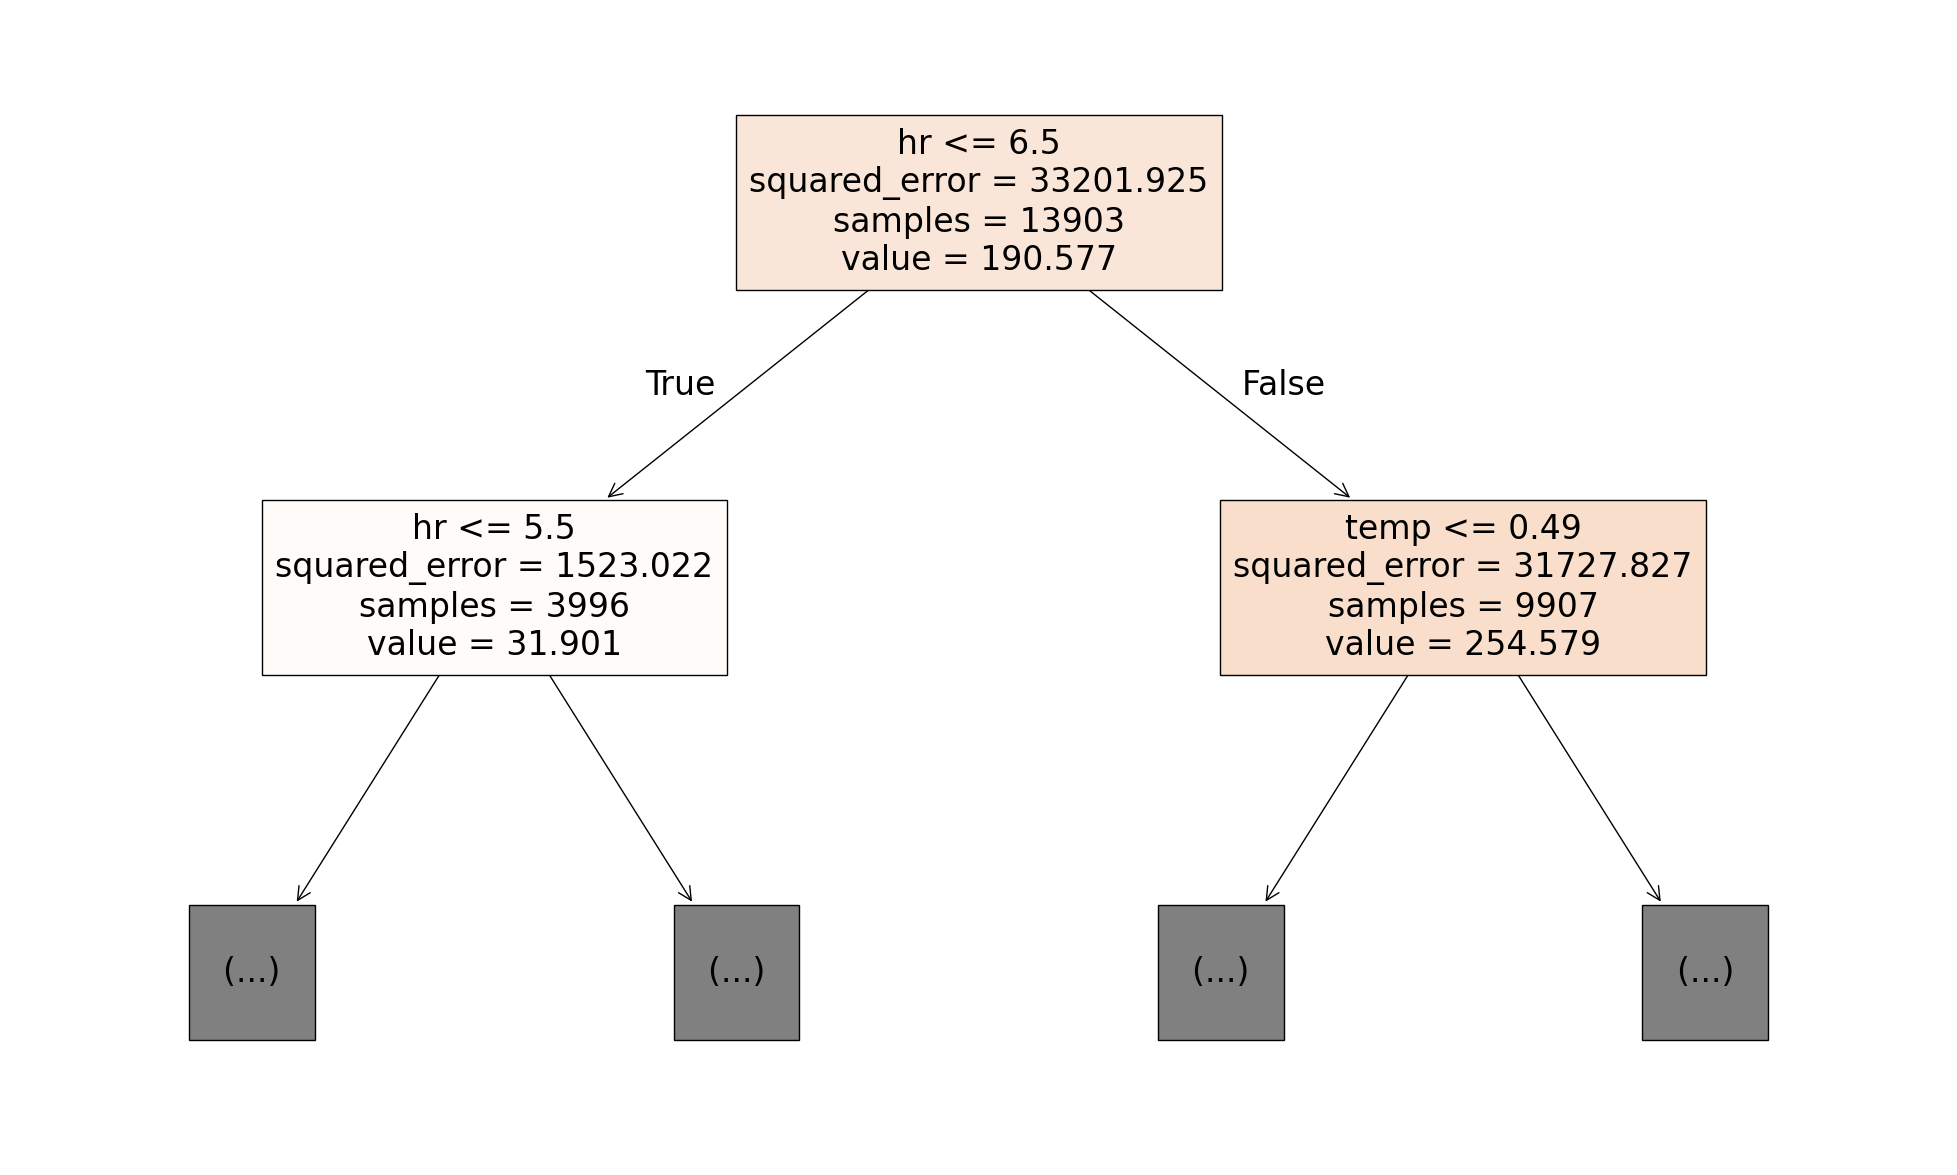

15


In [723]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))

plot_tree(tree_model,feature_names=X.columns,max_depth=1,filled=True)

plt.show()
print(tree_model.get_depth())

In [724]:
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, y_pred_forest)

forest_mse = mean_squared_error(y_test, y_pred_forest)

forest_rmse = np.sqrt(forest_mse)

forest_r2 = r2_score(y_test, y_pred_forest)

print("Random Forest Regression")
print("MAE:", forest_mae)
print("MSE:", forest_mse)
print("RMSE:", forest_rmse)
print("R2:", forest_r2)

Random Forest Regression
MAE: 24.902861502685077
MSE: 1769.8364453122304
RMSE: 42.06942411434022
R2: 0.9441082123801563


In [725]:
n_estimators_values = [50, 100, 150, 200, 250]

gradient_scores = []

for n in n_estimators_values:

    gradient_model = GradientBoostingRegressor(
        n_estimators=n,
        random_state=42
    )

    gradient_model.fit(X_train, y_train)

    y_pred_gradient = gradient_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_gradient)

    gradient_scores.append(mae)

    print("n_estimators =", n, "MAE =", mae)

best_n = n_estimators_values[np.argmin(gradient_scores)]

print("Best n_estimators:", best_n)

n_estimators = 50 MAE = 57.1679571341617
n_estimators = 100 MAE = 47.14865275808877
n_estimators = 150 MAE = 42.75950089727846
n_estimators = 200 MAE = 39.34648884639066
n_estimators = 250 MAE = 37.99952083882287
Best n_estimators: 250


In [726]:
gradient_model = GradientBoostingRegressor(n_estimators=best_n,random_state=42)

gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)

gradient_mae = mean_absolute_error(y_test, y_pred_gradient)
gradient_mse = mean_squared_error(y_test, y_pred_gradient)
gradient_rmse = np.sqrt(gradient_mse)
gradient_r2 = r2_score(y_test, y_pred_gradient)

print("Gradient Boosting Regression")
print("MAE:", gradient_mae)
print("MSE:", gradient_mse)
print("RMSE:", gradient_rmse)
print("R2:", gradient_r2)

Gradient Boosting Regression
MAE: 37.99952083882287
MSE: 3116.198484638678
RMSE: 55.82292078204685
R2: 0.9015898308874654


In [727]:
n_estimators_values = [50, 100, 150, 200]
max_depth_values = [2, 3, 4, 5]
learning_rate_values = [0.01, 0.05, 0.1, 0.2]

best_mae = float("inf")
best_xgb_n = None
best_xgb_depth = None
best_xgb_lr = None

for n in n_estimators_values:
    for depth in max_depth_values:
        for lr in learning_rate_values:
            xgb_model = XGBRegressor(n_estimators=n,max_depth=depth,learning_rate=lr,random_state=42)
            xgb_model.fit(X_train, y_train)
            y_pred_xgb = xgb_model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred_xgb)

            print("n_estimators =", n,"max_depth =", depth,"learning_rate =", lr,"MAE =", mae)

            if mae < best_mae:
                best_mae = mae
                best_xgb_n = n
                best_xgb_depth = depth
                best_xgb_lr = lr

print("Best n_estimators:", best_xgb_n)
print("Best max_depth:", best_xgb_depth)
print("Best learning_rate:", best_xgb_lr)
print("Best MAE:", best_mae)

n_estimators = 50 max_depth = 2 learning_rate = 0.01 MAE = 115.87640380859375
n_estimators = 50 max_depth = 2 learning_rate = 0.05 MAE = 82.02520751953125
n_estimators = 50 max_depth = 2 learning_rate = 0.1 MAE = 69.8034439086914
n_estimators = 50 max_depth = 2 learning_rate = 0.2 MAE = 64.29936981201172
n_estimators = 50 max_depth = 3 learning_rate = 0.01 MAE = 111.06195068359375
n_estimators = 50 max_depth = 3 learning_rate = 0.05 MAE = 69.8933334350586
n_estimators = 50 max_depth = 3 learning_rate = 0.1 MAE = 57.05118179321289
n_estimators = 50 max_depth = 3 learning_rate = 0.2 MAE = 43.8807258605957
n_estimators = 50 max_depth = 4 learning_rate = 0.01 MAE = 106.89910125732422
n_estimators = 50 max_depth = 4 learning_rate = 0.05 MAE = 55.70000457763672
n_estimators = 50 max_depth = 4 learning_rate = 0.1 MAE = 42.698326110839844
n_estimators = 50 max_depth = 4 learning_rate = 0.2 MAE = 33.929752349853516
n_estimators = 50 max_depth = 5 learning_rate = 0.01 MAE = 103.02051544189453
n_

In [728]:

xgb_model = XGBRegressor(n_estimators=best_xgb_n,max_depth=best_xgb_depth,learning_rate=best_xgb_lr,random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Regression
MAE: 25.68052101135254
MSE: 1646.416259765625
RMSE: 40.57605525141182
R2: 0.9480058550834656


In [729]:
results = pd.DataFrame({
    "Model": ["Linear Regression","KNN Regression","Decision Tree Regression","Random Forest Regression","Gradient Boosting Regression","XGBoost Regression"],

    "MAE": [linear_mae,knn_mae,tree_mae,forest_mae,gradient_mae,xgb_mae],

    "MSE": [linear_mse,knn_mse,tree_mse,forest_mse,gradient_mse,xgb_mse],

    "RMSE": [linear_rmse,knn_rmse,tree_rmse,forest_rmse,gradient_rmse,xgb_rmse],

    "R2": [linear_r2,knn_r2,tree_r2,forest_r2,gradient_r2,xgb_r2]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357
3,Random Forest Regression,24.902862,1769.836445,42.069424,0.944108
4,Gradient Boosting Regression,37.999521,3116.198485,55.822921,0.901590
5,XGBoost Regression,25.680521,1646.416260,40.576055,0.948006


In [730]:
results.sort_values(by="MAE")

,Model,MAE,MSE,RMSE,R2
3,Random Forest Regression,24.902862,1769.836445,42.069424,0.944108
5,XGBoost Regression,25.680521,1646.416260,40.576055,0.948006
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357
4,Gradient Boosting Regression,37.999521,3116.198485,55.822921,0.901590
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981


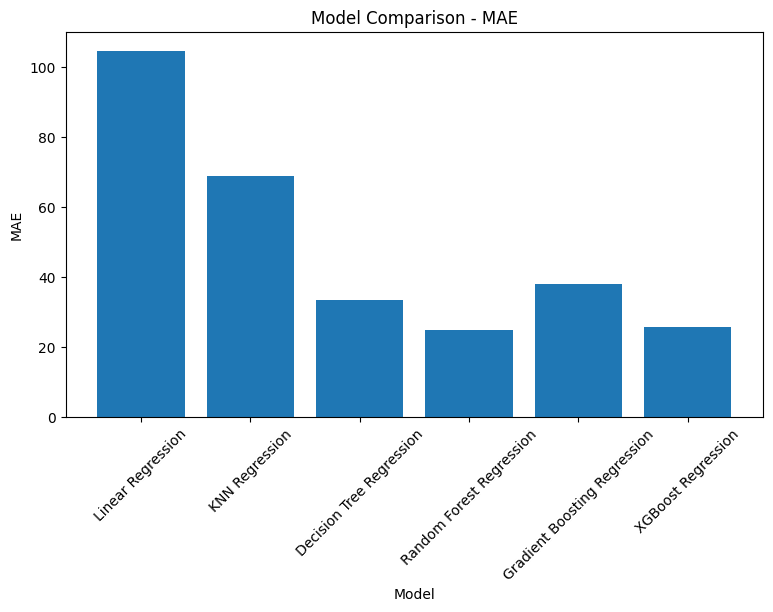

In [731]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"],results["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")
plt.xticks(rotation=45)
plt.show()

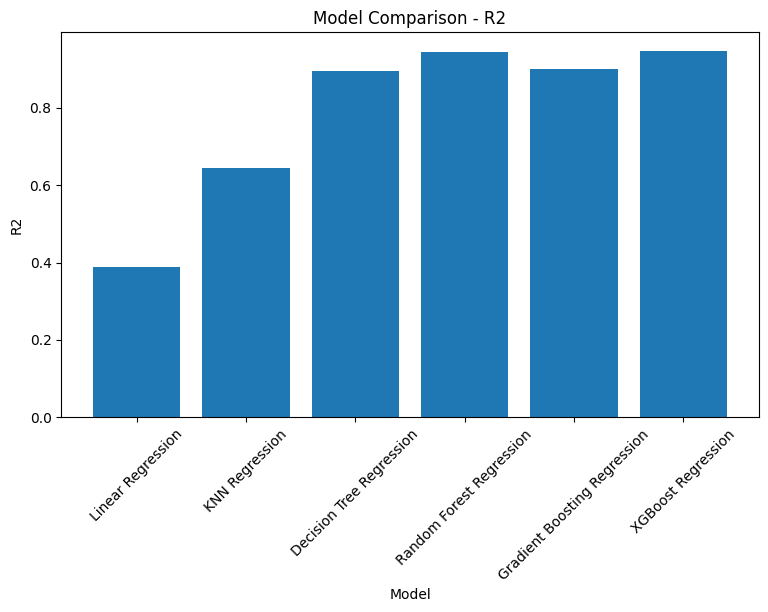

In [732]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"],results["R2"])

plt.xlabel("Model")
plt.ylabel("R2")
plt.title("Model Comparison - R2")
plt.xticks(rotation=45)
plt.show()

In [733]:
feature_importance = pd.DataFrame(tree_model.feature_importances_,index=X.columns,columns=["importance"])
feature_importance = feature_importance.sort_values(by="importance",ascending=False)
feature_importance

,importance
hr,0.617409
temp,0.114823
yr,0.081759
workingday,0.062675
hum,0.025636
season,0.023853
atemp,0.020015
weathersit,0.017168
mnth,0.015363
weekday,0.010415


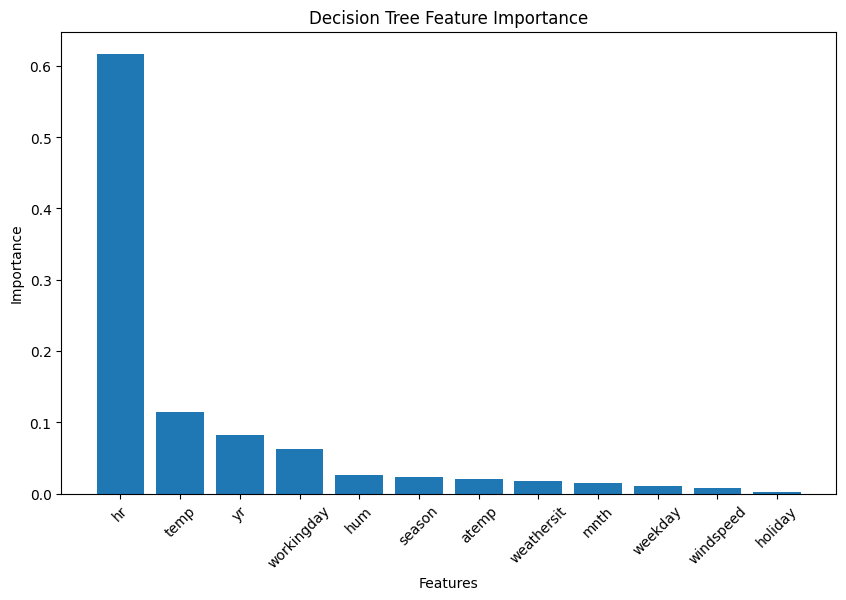

In [734]:
plt.figure(figsize=(10, 6))

plt.bar(feature_importance.index,feature_importance["importance"])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [735]:
forest_importance = pd.DataFrame(forest_model.feature_importances_,index=X.columns,columns=["importance"])
forest_importance = forest_importance.sort_values(by="importance",ascending=False)
forest_importance

,importance
hr,0.612154
temp,0.118983
yr,0.080795
workingday,0.057764
hum,0.026793
atemp,0.021805
season,0.021733
weathersit,0.018221
mnth,0.016530
weekday,0.012411


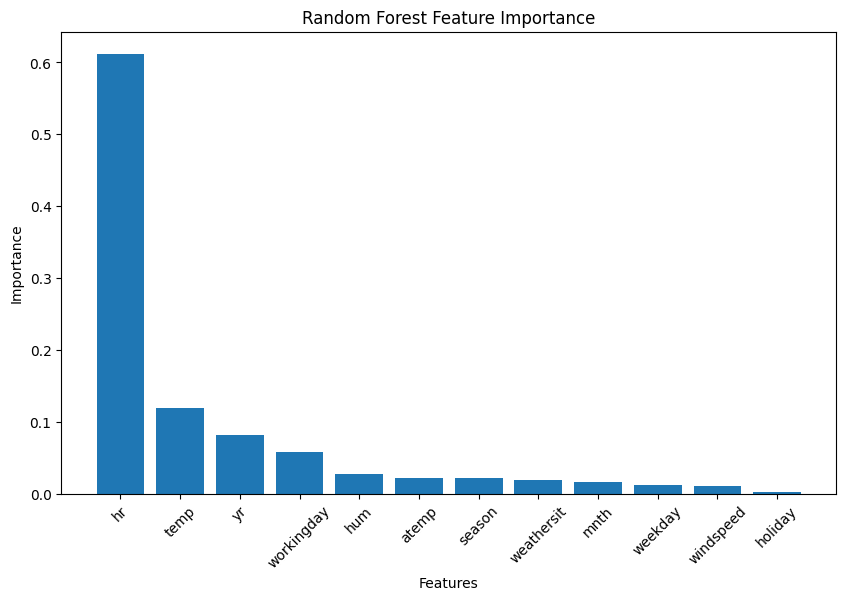

In [736]:
plt.figure(figsize=(10, 6))

plt.bar(
    forest_importance.index,
    forest_importance["importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [737]:
gradient_importance = pd.DataFrame(gradient_model.feature_importances_,index=X.columns,columns=["importance"])
gradient_importance = gradient_importance.sort_values(by="importance",ascending=False)
gradient_importance

,importance
hr,0.615932
workingday,0.097848
temp,0.089603
yr,0.087409
atemp,0.045217
season,0.023717
hum,0.013481
weathersit,0.012013
mnth,0.006869
weekday,0.005883


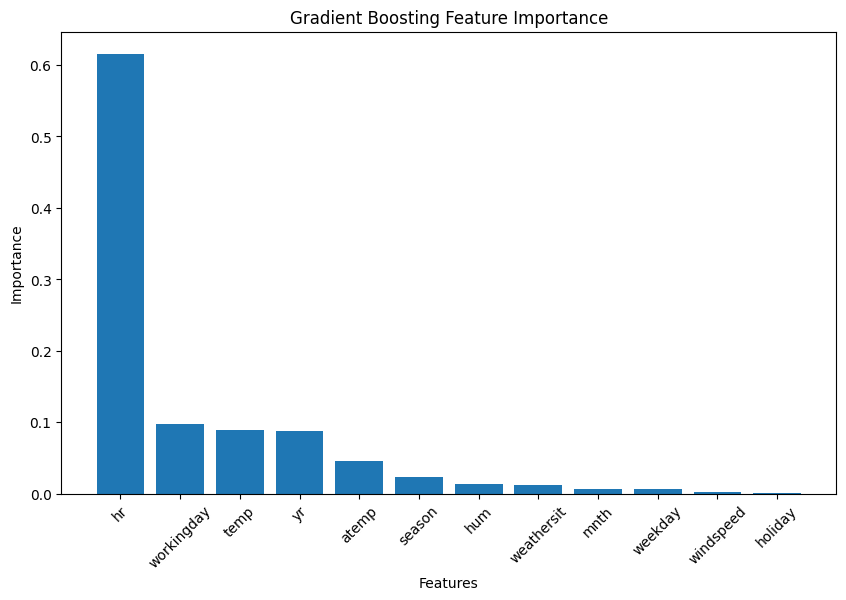

In [738]:
plt.figure(figsize=(10, 6))
plt.bar(gradient_importance.index,gradient_importance["importance"])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [739]:
xgb_importance = pd.DataFrame(xgb_model.feature_importances_,index=X.columns,columns=["importance"])
xgb_importance = xgb_importance.sort_values(by="importance",ascending=False)
xgb_importance

,importance
hr,0.248666
workingday,0.208852
yr,0.190943
temp,0.109485
season,0.075639
atemp,0.063494
weathersit,0.045658
mnth,0.015812
hum,0.014206
weekday,0.012521


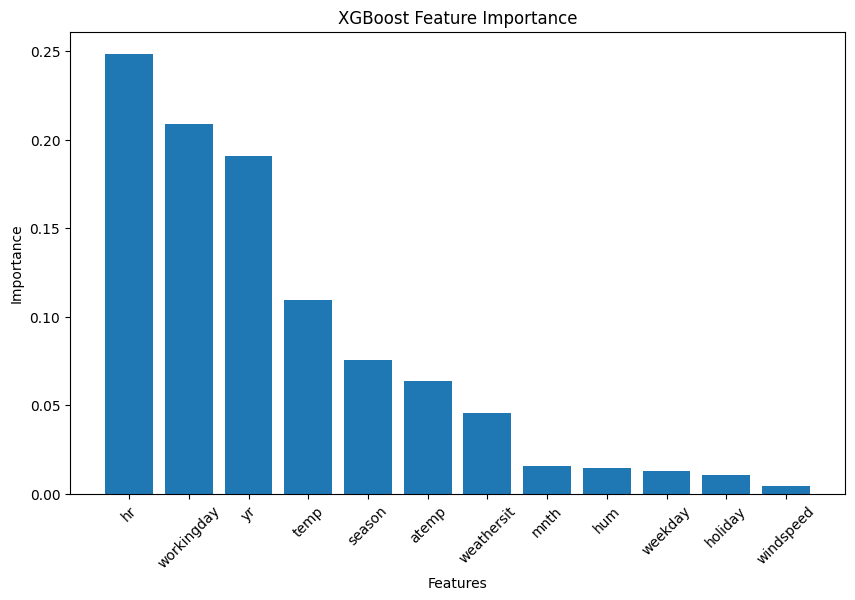

In [740]:
plt.figure(figsize=(10, 6))

plt.bar(xgb_importance.index,xgb_importance["importance"])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)

plt.show()

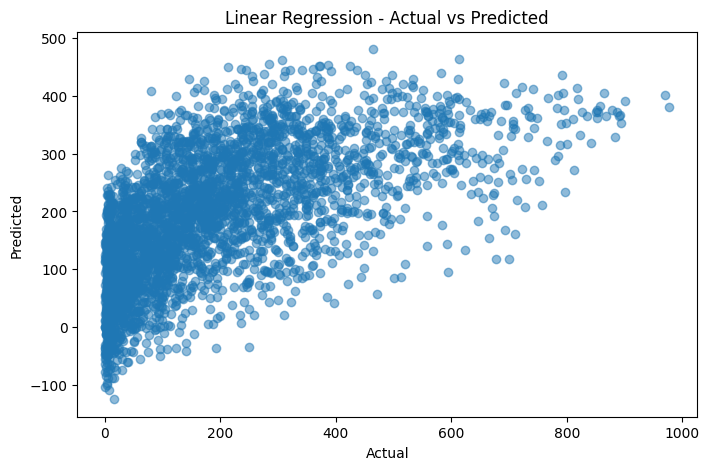

In [741]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_linear,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

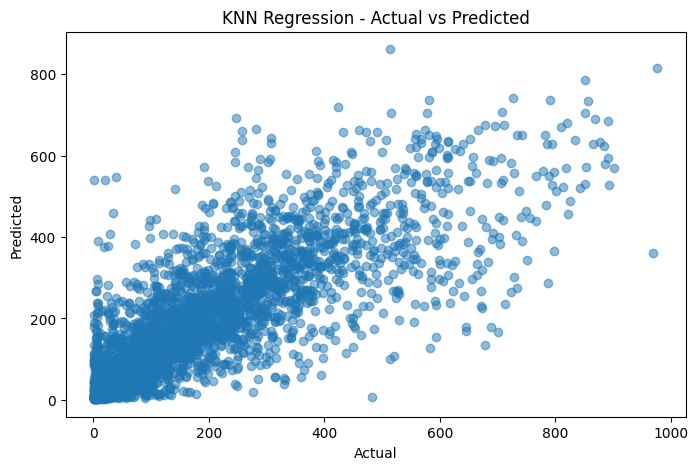

In [742]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_knn,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN Regression - Actual vs Predicted")

plt.show()

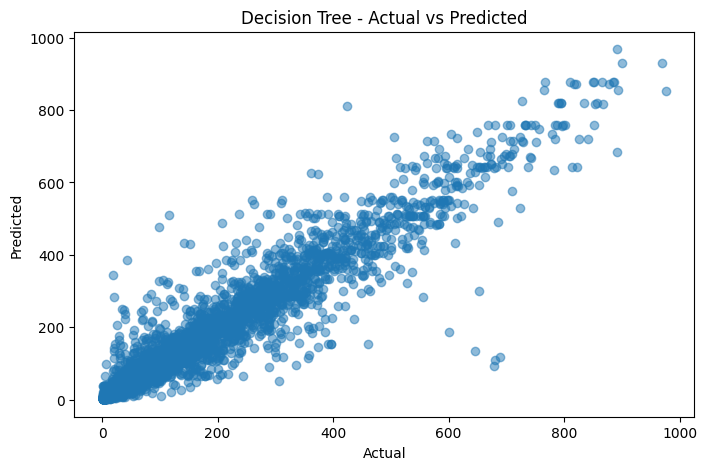

In [743]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_tree,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree - Actual vs Predicted")

plt.show()

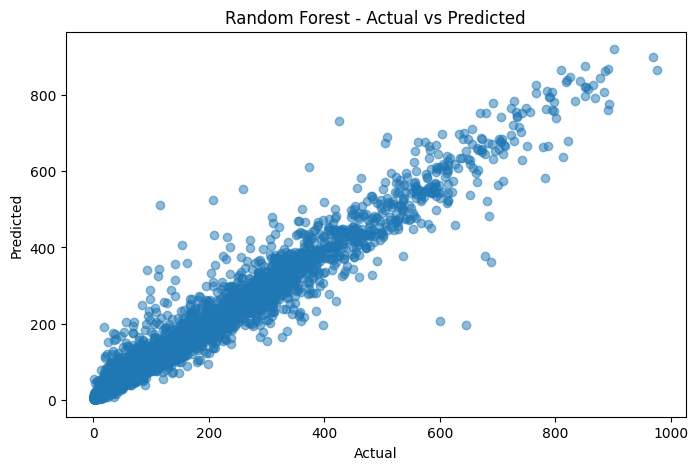

In [744]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_forest, alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Actual vs Predicted")

plt.show()

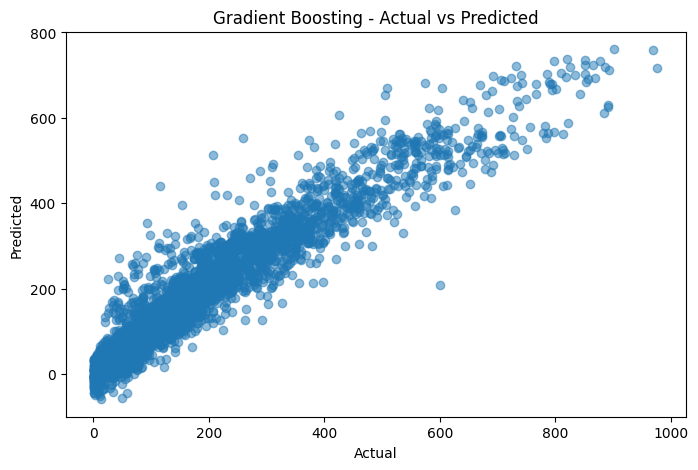

In [745]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_gradient, alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting - Actual vs Predicted")

plt.show()

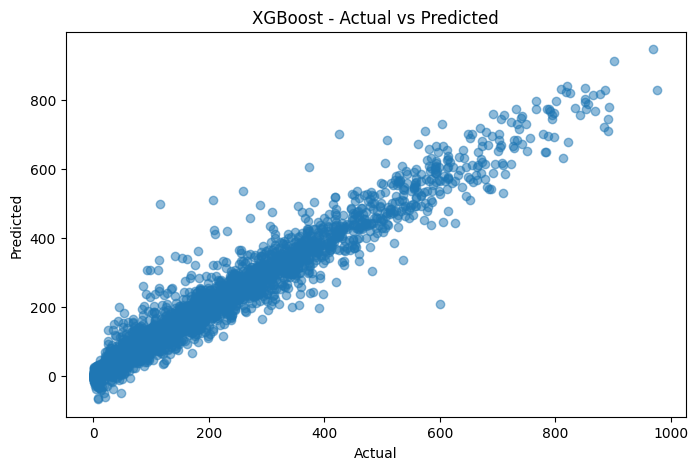

In [746]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost - Actual vs Predicted")

plt.show()

In [747]:
new_data = pd.DataFrame({
    "season": [2],
    "yr": [1],
    "mnth": [6],
    "hr": [18],
    "holiday": [0],
    "weekday": [2],
    "workingday": [1],
    "weathersit": [1],
    "temp": [0.60],
    "atemp": [0.58],
    "hum": [0.55],
    "windspeed": [0.20]
})

new_data

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2,1,6,18,0,2,1,1,0.6,0.58,0.55,0.2


In [748]:
new_data_scaled = scaler.transform(new_data)

linear_prediction = linear_model.predict(new_data_scaled)

print("Linear Regression Prediction:",linear_prediction[0])

Linear Regression Prediction: 319.4717212742888


In [749]:
knn_prediction = knn_model.predict(new_data_scaled)

print("KNN Prediction:",knn_prediction[0])

KNN Prediction: 421.0


In [750]:
tree_prediction = tree_model.predict(new_data)

print("Decision Tree Prediction:",tree_prediction[0])

Decision Tree Prediction: 733.7333333333333


In [751]:
forest_prediction = forest_model.predict(new_data)

print("Random Forest Prediction:",forest_prediction[0])

Random Forest Prediction: 758.4


In [752]:
gradient_prediction = gradient_model.predict(new_data)

print("Gradient Boosting Prediction:", gradient_prediction[0])

Gradient Boosting Prediction: 585.4588193321147


In [753]:
xgb_prediction = xgb_model.predict(new_data)

print("XGBoost Prediction:", xgb_prediction[0])

XGBoost Prediction: 688.42316


In [754]:
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357
3,Random Forest Regression,24.902862,1769.836445,42.069424,0.944108
4,Gradient Boosting Regression,37.999521,3116.198485,55.822921,0.901590
5,XGBoost Regression,25.680521,1646.416260,40.576055,0.948006


In [755]:
print("Lowest MAE:")
print(results.loc[results["MAE"].idxmin()])

Lowest MAE:
Model    Random Forest Regression
MAE                     24.902862
MSE                   1769.836445
RMSE                    42.069424
R2                       0.944108
Name: 3, dtype: object


In [756]:
print("Highest R2:")
print(results.loc[results["R2"].idxmax()])

Highest R2:
Model    XGBoost Regression
MAE               25.680521
MSE              1646.41626
RMSE              40.576055
R2                 0.948006
Name: 5, dtype: object
